## FFNN (Feed Forward Neural Network) Keras 
- With 0 = Negative, 1 = Positive & 2 = Neutral

# Sharvari Shewdikar

In [29]:
# pip install tensorflow=2.10.0

In [1]:
# Import libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

In [2]:
# Sample customer feedback texts

texts = [
    "The customer service was excellent",
    "Fast delivery and good packaging",
    "I am very satisfied with the product",
    "The support team was helpful",
    "Amazing quality and great experience",
    "Very easy to use application",
    "The website is user friendly",
    "Quick response from the company",

    "The product arrived damaged",
    "Very poor customer support",
    "I am unhappy with the service",
    "Delivery was extremely late",
    "The application keeps crashing",
    "Terrible experience overall",
    "The quality is very bad",
    "Waste of money",
    "The product quality is good but the delivery was slow"
]

# Labels
# 1 = Positive
# 0 = Negative
# 2 = Neutral

labels = np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2
])

In [3]:
## Vectorization using TF-IDF 
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(texts).toarray()

print("Vocabulary:", vectorizer.get_feature_names_out())

print("\nNumeric Representation:")
print(X)

Vocabulary: ['amazing' 'application' 'arrived' 'bad' 'company' 'crashing' 'customer'
 'damaged' 'delivery' 'easy' 'excellent' 'experience' 'extremely' 'fast'
 'friendly' 'good' 'great' 'helpful' 'keeps' 'late' 'money' 'overall'
 'packaging' 'poor' 'product' 'quality' 'quick' 'response' 'satisfied'
 'service' 'slow' 'support' 'team' 'terrible' 'unhappy' 'use' 'user'
 'waste' 'website']

Numeric Representation:
[[0.         0.         0.         0.         0.         0.
  0.5495197  0.         0.         0.         0.62932996 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.5495197
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.426268   0.         0.         0.
  0.         0.54426214 0.         0.47523999 0.         0.
  0.

In [4]:
## Building FFNN 
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X.shape[1],)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

d:\workspace\SRH\Semester_2\NLP\WA\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 657 (2.57 KB)

 Trainable params: 657 (2.57 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
## training the model 
history = model.fit(X, labels, epochs=100, batch_size=2)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5294 - loss: 0.6204 
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5294 - loss: 0.6136 
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5294 - loss: 0.6070     
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5882 - loss: 0.6007 
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6471 - loss: 0.5943 
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6471 - loss: 0.5875 
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6471 - loss: 0.5808     
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7059 - loss: 0.5741     
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7059 - loss: 0.5674 
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7647 - loss: 0.5601 
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7647 - loss: 0.5530 
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 

In [7]:
## testing the model
test_texts = [
    "The product is amazing and the support was great",
    "I am disappointed with the quality and delivery"
]

new_vector = vectorizer.transform(test_texts).toarray()

# make predictions
predictions = model.predict(new_vector)

print("Probability:", predictions[0][0])

if predictions[0][0] > 0.5:
    print("Predicted Label: Positive")  
else:
    print("Predicted Label: Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Probability: 0.9422307
Predicted Label: Positive


In [34]:
# pip install matplotlib

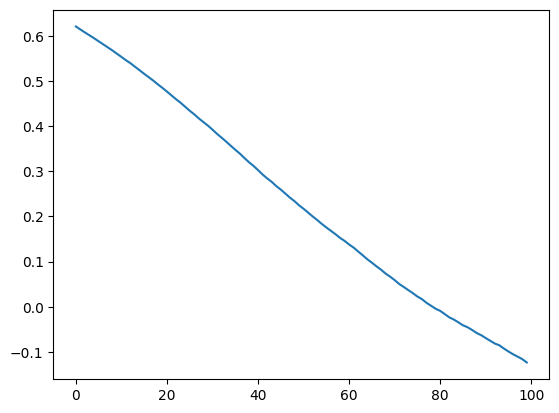

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


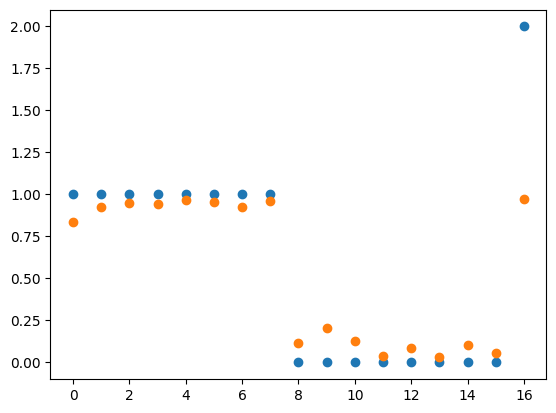

In [8]:
## visualization

import matplotlib.pyplot as plt

# training loss
plt.plot(history.history['loss'])
plt.show()

# predictions
predictions = model.predict(X).flatten()

plt.scatter(range(len(labels)), labels)
plt.scatter(range(len(predictions)), predictions)
plt.show()